<a href="https://colab.research.google.com/github/laksamanaap/244107020021-machine-leaning-course-2026-/blob/main/JS06/JS06_TugasLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
# Import library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [230]:
# Load dataset
df = pd.read_csv('voice.csv')

df.head()

print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah data: 3168
Jumlah kolom: 21


In [231]:
# Pisah fitur dan label
X = df.drop('label', axis=1)
y = df['label']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Cek distribusi
print(y.value_counts())

Shape X: (3168, 20)
Shape y: (3168,)
label
male      1584
female    1584
Name: count, dtype: int64


In [232]:
# Training SVM
def train_svm(X_train, X_test, y_train, y_test, kernel):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return model, accuracy

In [233]:
# Split data 70:30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train_70))
print("Data testing :", len(X_test_30))

Data training: 2217
Data testing : 951


In [234]:
# SVM Kernel linear
model_linear_70, acc_linear_70 = train_svm(
    X_train_70,
    X_test_30,
    y_train_70,
    y_test_30,
    kernel='linear'
)

print(f"Accuracy Linear 70:30 = {acc_linear_70:.4f}")

Accuracy Linear 70:30 = 0.9790


In [235]:
# SVM Kernel polynomial 70:30
model_poly_70, acc_poly_70 = train_svm(
    X_train_70,
    X_test_30,
    y_train_70,
    y_test_30,
    kernel='poly'
)

print(f"Accuracy Polynomial 70:30 = {acc_poly_70:.4f}")

Accuracy Polynomial 70:30 = 0.9600


In [236]:
# SVM Kernel RBG 70:30
model_rbf_70, acc_rbf_70 = train_svm(
    X_train_70,
    X_test_30,
    y_train_70,
    y_test_30,
    kernel='rbf'
)

print(f"Accuracy RBF 70:30 = {acc_rbf_70:.4f}")

Accuracy RBF 70:30 = 0.9832


In [237]:
# Split data 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train_80))
print("Data testing :", len(X_test_20))

Data training: 2534
Data testing : 634


In [238]:
# Linear 80:20
model_linear_80, acc_linear_80 = train_svm(
    X_train_80,
    X_test_20,
    y_train_80,
    y_test_20,
    kernel='linear'
)

print(f"Accuracy Linear 80:20 = {acc_linear_80:.4f}")

Accuracy Linear 80:20 = 0.9748


In [239]:
# Polynomial 80:20
model_poly_80, acc_poly_80 = train_svm(
    X_train_80,
    X_test_20,
    y_train_80,
    y_test_20,
    kernel='poly'
)

print(f"Accuracy Polynomial 80:20 = {acc_poly_80:.4f}")

Accuracy Polynomial 80:20 = 0.9558


In [240]:
# RBF 80:20
model_rbf_80, acc_rbf_80 = train_svm(
    X_train_80,
    X_test_20,
    y_train_80,
    y_test_20,
    kernel='rbf'
)

print(f"Accuracy RBF 80:20 = {acc_rbf_80:.4f}")

Accuracy RBF 80:20 = 0.9826


In [241]:
# Tabulasi performa
results = pd.DataFrame({
    'Split': [
        '70:30',
        '70:30',
        '70:30',
        '80:20',
        '80:20',
        '80:20'
    ],
    'Kernel': [
        'Linear',
        'Polynomial',
        'RBF',
        'Linear',
        'Polynomial',
        'RBF'
    ],
    'Accuracy': [
        acc_linear_70,
        acc_poly_70,
        acc_rbf_70,
        acc_linear_80,
        acc_poly_80,
        acc_rbf_80
    ]
})

results['Accuracy (%)'] = results['Accuracy'] * 100

results

,Split,Kernel,Accuracy,Accuracy (%)
0,70:30,Linear,0.978970,97.896951
1,70:30,Polynomial,0.960042,96.004206
2,70:30,RBF,0.983176,98.317560
3,80:20,Linear,0.974763,97.476341
4,80:20,Polynomial,0.955836,95.583596
5,80:20,RBF,0.982650,98.264984


In [242]:
# Cari model terbaik
best_model = results.loc[results['Accuracy'].idxmax()]

print("Model terbaik:")
print(best_model)

Model terbaik:
Split              70:30
Kernel               RBF
Accuracy        0.983176
Accuracy (%)    98.31756
Name: 2, dtype: object


In [243]:
# Conclussion matrix model
y_pred_rbf_70 = model_rbf_70.predict(X_test_30)

cm = confusion_matrix(y_test_30, y_pred_rbf_70)

print(cm)

[[467   9]
 [  7 468]]


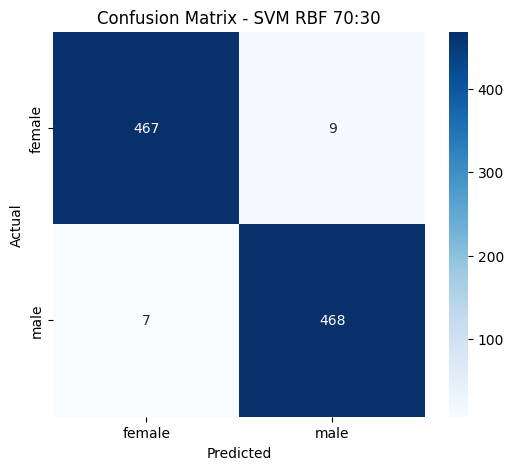

              precision    recall  f1-score   support

      female       0.99      0.98      0.98       476
        male       0.98      0.99      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



In [244]:
# Visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['female', 'male'],
    yticklabels=['female', 'male']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM RBF 70:30')

plt.show()

print(
    classification_report(
        y_test_30,
        y_pred_rbf_70
    )
)

## Klasifikasi Siang dan Malam dengan Histogram

In [245]:
# Import Library
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [246]:
# Load semua gambar
def load_images(img_dir):

    images = []
    labels = []

    img_dir = Path(img_dir)

    for label_name in ['day', 'night']:

        label_dir = img_dir / label_name

        for file in label_dir.glob('*'):

            img = cv2.imread(str(file))

            if img is not None:
                images.append(img)
                labels.append(label_name)

    return images, labels

# Load training testing
train_images, train_labels = load_images(
    'images/training'
)

test_images, test_labels = load_images(
    'images/test'
)

print("Training:", len(train_images))
print("Testing :", len(test_images))

Training: 240
Testing : 160


In [247]:
# Gabungkan dataset

images = train_images + test_images
labels = train_labels + test_labels

print("Total images:", len(images))

Total images: 400


In [248]:
# Ekstraksi fitur historigram
def extract_histogram(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256]
    )

    # Normalisasi histogram
    hist = cv2.normalize(
        hist,
        hist
    )

    return hist.flatten()

In [249]:
# Ekstraksi Historigram semua gambar
X_hist = np.array([
    extract_histogram(img)
    for img in images
])

y_hist = np.array(labels)

print("Shape fitur:", X_hist.shape)
print("Shape label:", y_hist.shape)

Shape fitur: (400, 256)
Shape label: (400,)


In [250]:
# Encode label
y_hist = np.where(
    y_hist == 'day',
    1,
    0
)

In [251]:
# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_hist,
    y_hist,
    test_size=0.20,
    random_state=42,
    stratify=y_hist
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (320, 256)
Testing : (80, 256)


In [252]:
# Model SVM RBF
model_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    ))
])

model_rbf.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=1))])

In [253]:
# Eval
y_pred = model_rbf.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9875
Accuracy: 98.75%


In [254]:
# Hyperparameter
C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.001, 0.01, 0.1]

results_rbf = []

for C in C_values:

    for gamma in gamma_values:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(
                kernel='rbf',
                C=C,
                gamma=gamma
            ))
        ])

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        results_rbf.append({
            'C': C,
            'Gamma': gamma,
            'Accuracy': accuracy
        })

In [255]:
# Liat hasil tuning
results_rbf = pd.DataFrame(
    results_rbf
)

results_rbf['Accuracy (%)'] = (
    results_rbf['Accuracy'] * 100
)

results_rbf.sort_values(
    'Accuracy',
    ascending=False
)

# Ambil parameter terbaik
best_rbf = results_rbf.loc[
    results_rbf['Accuracy'].idxmax()
]

print(best_rbf)

C                10.0
Gamma            0.01
Accuracy          1.0
Accuracy (%)    100.0
Name: 10, dtype: object


In [256]:
# Train model terbaik
best_C = best_rbf['C']
best_gamma = best_rbf['Gamma']

best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=best_C,
        gamma=best_gamma
    ))
])

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(X_test)

best_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Best C       : {best_C}")
print(f"Best Gamma   : {best_gamma}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

Best C       : 10.0
Best Gamma   : 0.01
Best Accuracy: 1.0000
Best Accuracy: 100.00%


In [257]:
y_pred = model_rbf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9875
Accuracy: 98.75%


In [258]:
C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.001, 0.01, 0.1]

results_rbf = []

for C in C_values:
    for gamma in gamma_values:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(
                kernel='rbf',
                C=C,
                gamma=gamma
            ))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        results_rbf.append({
            'C': C,
            'Gamma': gamma,
            'Accuracy': accuracy
        })

In [259]:
results_rbf = pd.DataFrame(results_rbf)

results_rbf['Accuracy (%)'] = (
    results_rbf['Accuracy'] * 100
)

results_rbf.sort_values(
    'Accuracy',
    ascending=False
)

,C,Gamma,Accuracy,Accuracy (%)
14,100.0,0.01,1.0000,100.00
10,10.0,0.01,1.0000,100.00
6,1.0,0.01,0.9875,98.75
4,1.0,scale,0.9875,98.75
8,10.0,scale,0.9875,98.75
9,10.0,0.001,0.9875,98.75
12,100.0,scale,0.9875,98.75
13,100.0,0.001,0.9875,98.75
5,1.0,0.001,0.9750,97.50
7,1.0,0.1,0.9625,96.25


Berdasarkan hasil pengujian, model SVM dengan kernel RBF memberikan performa terbaik dibandingkan kernel linear dan polynomial pada kedua skenario pembagian data. Pada split 70:30, kernel RBF memperoleh akurasi sebesar 98,32%, sedangkan pada split 80:20 memperoleh akurasi sebesar 98,26%. Kernel polynomial memberikan akurasi paling rendah, yaitu 96,00% pada split 70:30 dan 95,58% pada split 80:20. Hal ini menunjukkan bahwa kernel RBF mampu menangkap hubungan non-linear pada fitur dataset voice dengan lebih baik dibandingkan kernel lainnya

Kemudian tugas kedua dilakukan klasifikasi citra siang dan malam menggunakan Support Vector Machine dengan kernel RBF. Fitur yang digunakan adalah histogram grayscale dengan 256 bin. Dataset dibagi menggunakan rasio 80:20 untuk data training dan testing. Selanjutnya dilakukan eksperimen terhadap hyperparameter C dan gamma untuk memperoleh kombinasi yang menghasilkan akurasi terbaik. Model dengan kombinasi hyperparameter terbaik kemudian digunakan sebagai model akhir dan performanya dievaluasi menggunakan akurasi data testing